# Affective signals — characterization & simple-detector exploration

**Goal.** Understand the shape, scale, and noise of the A/V/D signals on this
recording, so we can design a *single-principle* event detector that is much
simpler than the current `affective_events` pipeline. Each section asks one
question and answers it with a print or a plot.

The premise (from looking at your hand-marked screenshots): an event is a
**sustained excursion of the signal away from its slowly-moving local
baseline**, lasting a few seconds. If that hypothesis is right, we should be
able to read sensible values for *baseline window width*, *threshold*, and
*minimum duration* directly off the plots in this notebook — and replace the
whole multi-detector pipeline with ~80 lines of code.

## How to use

1. Make sure your signals, VAD, and (optionally) audio are loaded into the
   kernel.
2. Edit the **CONFIG** cell below to point at your variables.
3. *Run all cells.*
4. Export to HTML and share back:
   `jupyter nbconvert --to html --execute explore_signals.ipynb`

## Sections

1. Sanity check & global stats
2. Signal value distributions (speech vs silence)
3. VAD interval structure
4. Per-frame speech coverage
5. Local baseline at multiple window widths
6. Deviation magnitude distribution — *the diagnostic that sets the threshold*
7. Tentative detector — parameter sweep
8. Zoom into your hand-marked regions with detection overlay
9. Full-recording overview


In [41]:
import os
import json
import numpy as np
npz_path = os.path.normpath('/workspace/labeling/jamespiper-2026-2-9__14-44-54/8c8d972078e96826__20260429T134229Z.npz')
npz_content = np.load(npz_path)

json_path = os.path.normpath('/workspace/labeling/jamespiper-2026-2-9__14-44-54/8c8d972078e96826__20260429T134229Z.json')
with open(json_path, 'r') as f:
    json_content = json.load(f)

json_content.keys()



dict_keys(['schema_version', 'session_id', 'recording_id', 'audio_path', 'audio_sr', 'audio_duration_sec', 'config', 'config_hash', 'signals_meta', 'signals_data_path', 'vad_intervals', 'blocks', 'events', 'labels', 'created_at', 'last_updated_at', 'notes'])

In [42]:
npz_content.keys()

KeysView(NpzFile '/workspace/labeling/jamespiper-2026-2-9__14-44-54/8c8d972078e96826__20260429T134229Z.npz' with keys: arousal, valence, dominance)

In [43]:
audio_sr = json_content['audio_sr']
vad_intervals = json_content['vad_intervals']

In [44]:
config = json_content['config']

In [45]:
config

{'vad_merge_gap_sec': 0.5,
 'min_speech_block_sec': 0.75,
 'usable_speech_coverage': 0.6,
 'core_speech_coverage': 0.8,
 'boundary_margin_sec': 1.5,
 'smooth_median_sec': 1.0,
 'scale_floor_frac': 0.5,
 'local_context_radius_sec': 90.0,
 'exclude_candidate_radius_sec': 8.0,
 'min_context_speech_sec': 20.0,
 'min_block_for_deviation_sec': 3.5,
 'min_block_for_excursion_sec': 8.0,
 'excursion_enter_z': 2.0,
 'excursion_exit_z': 1.0,
 'excursion_min_duration_sec': 3.0,
 'excursion_merge_gap_sec': 1.5,
 'excursion_to_block_ratio': 0.7,
 'min_block_for_regime_shift_sec': 20.0,
 'regime_shift_min_pre_sec': 6.0,
 'regime_shift_min_post_sec': 6.0,
 'regime_shift_edge_margin_sec': 2.0,
 'min_block_for_ramp_sec': 20.0,
 'ramp_min_duration_sec': 12.0,
 'model_penalty_c': 1.0,
 'baseline_departure_z': 1.75,
 'min_absolute_effect': None,
 'short_gap_max_sec': 3.0,
 'short_gap_min_delta_z': 1.5,
 'cross_block_consistency_z': 1.0,
 'cross_block_max_gap_sec': 60.0,
 'enable_episode_aggregation': True,

In [46]:
npz_content.keys()

KeysView(NpzFile '/workspace/labeling/jamespiper-2026-2-9__14-44-54/8c8d972078e96826__20260429T134229Z.npz' with keys: arousal, valence, dominance)

In [47]:
# ============================================================================
# CONFIG — edit this cell to point at your variables, then run all cells.
# ============================================================================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view

# --- Continuous A/V/D signals ------------------------------------------------
# Map each signal name to a 1-D numpy array on a regular hop grid.
# Add/remove entries to match what you have loaded.
SIGNALS = {
    "arousal": npz_content['arousal'],
    "valence": npz_content['valence'],
    "dominance": npz_content['dominance'],
}

HOP_SEC = 0.25      # spacing between consecutive frames
WINDOW_SEC = 3.5    # receptive field (audio extent each frame summarizes)

# --- VAD intervals -----------------------------------------------------------
# A list of (start_sec, end_sec) speech intervals.
# If you have a `Vad` object, pass `list(vad.intervals)`.
VAD = list(vad_intervals)

# --- Hand-marked events from your screenshots --------------------------------
# Approximate timestamps — refine these if you have more precise ranges.
# The more accurate, the better the threshold calibration.
# Format: (signal_name, label, start_sec, end_sec)
MARKED_EVENTS = [
    ("arousal", "Positive Arousal",        7.65 * 60,  7.85 * 60),
    ("arousal", "Negative Arousal",       43.95 * 60, 44.10 * 60),
    ("arousal", "High arousal block",     46.65 * 60, 46.8 * 60),
    ("arousal", "Negative Arousal",       51.90 * 60, 52.10 * 60),
    ("valence", "Positive Valence",        7.65 * 60,  7.85 * 60),
    ("valence", "Negative Valence",        8.50 * 60,  8.65 * 60),
    ("valence", "Negative Valence",        9.95 * 60, 10.10 * 60),
    ("valence", "Positive Valence",       15.10 * 60, 15.30 * 60),
    ("valence", "Negative Valence",       16.45 * 60, 16.60 * 60),
]

# --- Time windows shown in your screenshots — used for zoom plots ------------
ZOOM_WINDOWS_SEC = [
    ( 7.5 * 60, 12.5 * 60),
    (14.5 * 60, 19.0 * 60),
    (42.5 * 60, 47.5 * 60),
    (49.0 * 60, 54.0 * 60),
]

# --- Quality threshold (frames whose receptive window overlaps speech) -------
USABLE_COVERAGE = 0.6

print(f"Loaded {len(SIGNALS)} signals: {list(SIGNALS.keys())}")
print(f"Frame count: {len(next(iter(SIGNALS.values())))}")
print(f"Hop = {HOP_SEC}s, window = {WINDOW_SEC}s")
print(f"VAD intervals: {len(VAD)}")
print(f"Marked events: {len(MARKED_EVENTS)}")


Loaded 3 signals: ['arousal', 'valence', 'dominance']
Frame count: 17872
Hop = 0.25s, window = 3.5s
VAD intervals: 140
Marked events: 9


## 1. Sanity check & global stats

Per-signal range and robust scale. Tells us:

- whether values are bounded in [0, 1] (probability-like) or already z-scored
- whether different signals share a comparable scale, so a single threshold
  could plausibly cover both
- the **scaled MAD**, i.e. roughly "one z worth of signal" — useful when
  comparing the threshold we'll pick to the noise floor


In [48]:
def speech_coverage(n_frames, hop_sec, window_sec, vad_intervals):
    """Per-frame fraction of receptive window overlapping speech."""
    starts = np.arange(n_frames) * hop_sec
    ends = starts + window_sec
    cov = np.zeros(n_frames)
    for s, e in vad_intervals:
        ov_lo = np.maximum(starts, s)
        ov_hi = np.minimum(ends, e)
        cov += np.maximum(0.0, ov_hi - ov_lo)
    return cov / window_sec

n_frames = len(next(iter(SIGNALS.values())))
recording_dur_sec = n_frames * HOP_SEC + WINDOW_SEC
total_speech_sec = sum(e - s for s, e in VAD)
coverage = speech_coverage(n_frames, HOP_SEC, WINDOW_SEC, VAD)

print(f"Recording duration:    {recording_dur_sec/60:6.1f} min")
print(f"Total speech (raw VAD):{total_speech_sec/60:6.1f} min "
      f"({total_speech_sec/recording_dur_sec*100:.1f}%)")
print(f"Frames cov >= {USABLE_COVERAGE}:    {(coverage >= USABLE_COVERAGE).sum()} "
      f"({(coverage >= USABLE_COVERAGE).mean()*100:.1f}%)")
print()

rows = []
valid = coverage >= USABLE_COVERAGE
for name, sig in SIGNALS.items():
    vals = sig[valid]
    med = np.median(vals)
    mad = np.median(np.abs(vals - med))
    rows.append({
        "signal":          name,
        "n_valid":         int(valid.sum()),
        "min":             float(vals.min()),
        "p5":              float(np.percentile(vals, 5)),
        "median":          float(med),
        "p95":             float(np.percentile(vals, 95)),
        "max":             float(vals.max()),
        "mad":             float(mad),
        "scaled_mad":      float(1.4826 * mad),
    })
pd.DataFrame(rows).round(4)


Recording duration:      74.5 min
Total speech (raw VAD):  51.1 min (68.6%)
Frames cov >= 0.6:    11961 (66.9%)



,signal,n_valid,min,p5,median,p95,max,mad,scaled_mad
0,arousal,11961,0.0670,0.2690,0.4299,0.5741,0.7719,0.0634,0.0940
1,valence,11961,0.1325,0.2999,0.5251,0.7223,0.9061,0.0971,0.1440
2,dominance,11961,0.1243,0.3403,0.4748,0.5820,0.6760,0.0482,0.0714


## 2. Value distributions — speech vs silence frames

If silence frames have a wildly different distribution from speech frames,
we have to be careful not to bias the baseline by including them. The
*usable coverage* mask should already exclude most of the silence
contamination — this plot confirms.

We also expect speech values to be **roughly unimodal**. A bimodal
speech distribution would suggest there are two distinct speakers /
contexts / arousal regimes, and a single global baseline isn't enough.


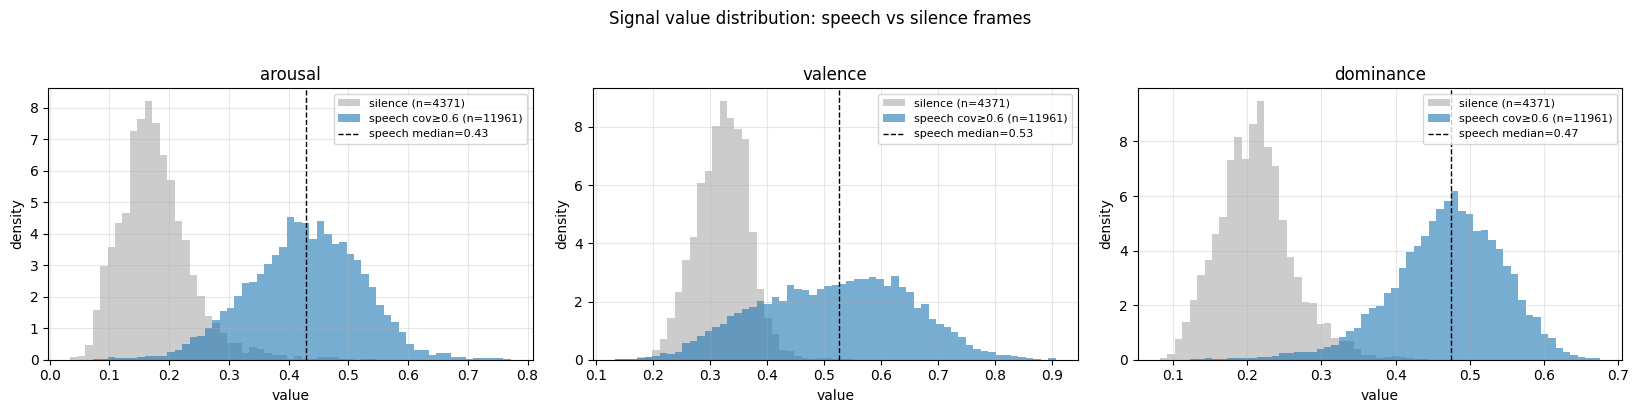

In [49]:
fig, axes = plt.subplots(1, len(SIGNALS), figsize=(5.5*len(SIGNALS), 4),
                         squeeze=False)
for ax, (name, sig) in zip(axes[0], SIGNALS.items()):
    in_speech = coverage >= USABLE_COVERAGE
    no_speech = coverage < 0.1

    bins = np.linspace(sig.min(), sig.max(), 60)
    if no_speech.any():
        ax.hist(sig[no_speech], bins=bins, alpha=0.4, density=True,
                color="gray", label=f"silence (n={no_speech.sum()})")
    ax.hist(sig[in_speech], bins=bins, alpha=0.6, density=True,
            color="C0",
            label=f"speech cov≥{USABLE_COVERAGE} (n={in_speech.sum()})")

    med = np.median(sig[in_speech])
    ax.axvline(med, color="k", ls="--", lw=1, label=f"speech median={med:.2f}")
    ax.set_xlabel("value")
    ax.set_ylabel("density")
    ax.set_title(name)
    ax.legend(loc="best", fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle("Signal value distribution: speech vs silence frames", y=1.02)
plt.tight_layout()
plt.show()


## 3. VAD interval structure

Two questions:

- **Block durations**: are most "speech blocks" longer than the kind of
  events we're looking for (5-25 s)? If yes, events fit inside blocks and
  we don't need a special cross-block detector.
- **Inter-block gaps**: how long are typical silences? If most are
  short (< 1-2 s), we can safely "bridge" them so events don't get cut
  by a brief breath.


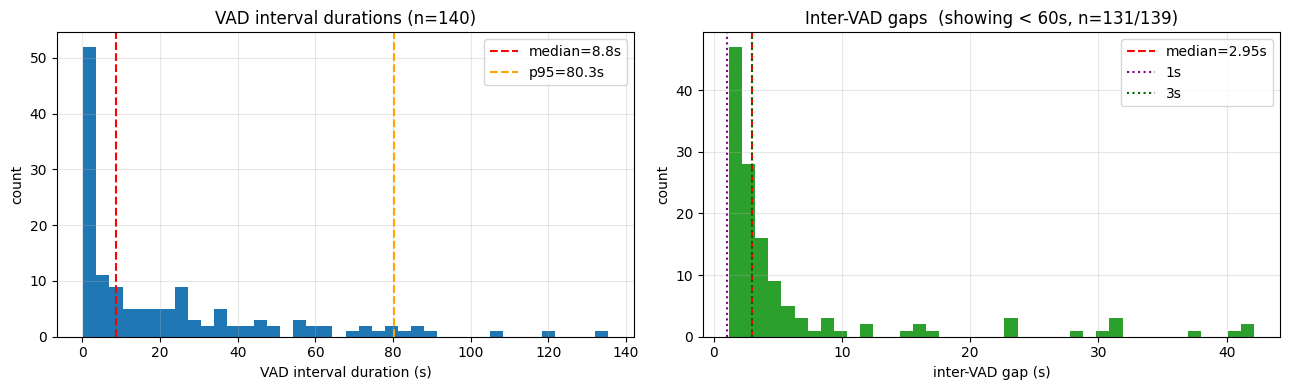

Speech: 51.1 min over 140 intervals
  duration   median=  8.8s  p25=  1.5s  p75= 32.4s  p95= 80.3s  max=135.4s
  gaps       median= 2.95s  p25= 1.83s  p75= 5.76s  p95= 60.7s  max=92.4s


In [50]:
durations = np.array([e - s for s, e in VAD])
gaps = np.array([VAD[i+1][0] - VAD[i][1] for i in range(len(VAD)-1)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(durations, bins=40, color="C0")
axes[0].axvline(np.median(durations), color="r", ls="--",
                label=f"median={np.median(durations):.1f}s")
axes[0].axvline(np.percentile(durations, 95), color="orange", ls="--",
                label=f"p95={np.percentile(durations, 95):.1f}s")
axes[0].set_xlabel("VAD interval duration (s)")
axes[0].set_ylabel("count")
axes[0].set_title(f"VAD interval durations (n={len(VAD)})")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

gaps_show = gaps[gaps < 60]
axes[1].hist(gaps_show, bins=40, color="C2")
axes[1].axvline(np.median(gaps), color="r", ls="--",
                label=f"median={np.median(gaps):.2f}s")
axes[1].axvline(1.0, color="purple", ls=":", lw=1.5, label="1s")
axes[1].axvline(3.0, color="darkgreen", ls=":", lw=1.5, label="3s")
axes[1].set_xlabel("inter-VAD gap (s)")
axes[1].set_ylabel("count")
axes[1].set_title(f"Inter-VAD gaps  (showing < 60s, n={(gaps<60).sum()}/{len(gaps)})")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Speech: {durations.sum()/60:.1f} min over {len(VAD)} intervals")
print(f"  duration   median={np.median(durations):5.1f}s  "
      f"p25={np.percentile(durations, 25):5.1f}s  "
      f"p75={np.percentile(durations, 75):5.1f}s  "
      f"p95={np.percentile(durations, 95):5.1f}s  "
      f"max={durations.max():.1f}s")
print(f"  gaps       median={np.median(gaps):5.2f}s  "
      f"p25={np.percentile(gaps, 25):5.2f}s  "
      f"p75={np.percentile(gaps, 75):5.2f}s  "
      f"p95={np.percentile(gaps, 95):5.1f}s  "
      f"max={gaps.max():.1f}s")


## 4. Per-frame speech coverage

Each frame summarizes a 3.5 s window. Frames whose window straddles
silence are unreliable. We mask out anything below `USABLE_COVERAGE`
in all subsequent steps.


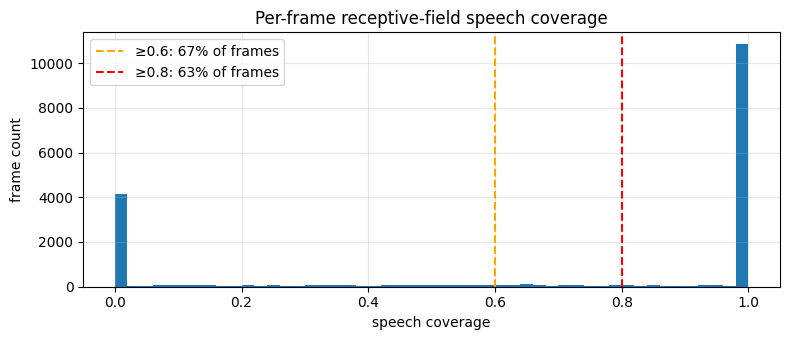

In [51]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(coverage, bins=50, color="C0")
for thr, c in [(USABLE_COVERAGE, "orange"), (0.8, "red")]:
    pct = (coverage >= thr).mean() * 100
    ax.axvline(thr, color=c, ls="--", label=f"≥{thr}: {pct:.0f}% of frames")
ax.set_xlabel("speech coverage")
ax.set_ylabel("frame count")
ax.set_title("Per-frame receptive-field speech coverage")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Local baseline at multiple window widths

This is the **central question** for the simple detector: how wide should
the baseline-tracking window be?

- Too narrow → the baseline hugs the events themselves; no events stand
  out (wiggle baseline).
- Too wide → drift across the recording is treated as a constant baseline,
  and quiet periods late in the recording may incorrectly score as events.

We plot four window widths overlaid on a representative zoom region with
your hand-marked events shaded. The "right" width is the one where the
black baseline line **passes underneath/around the marked events**, i.e.
the events visibly stick out above/below the baseline trace.


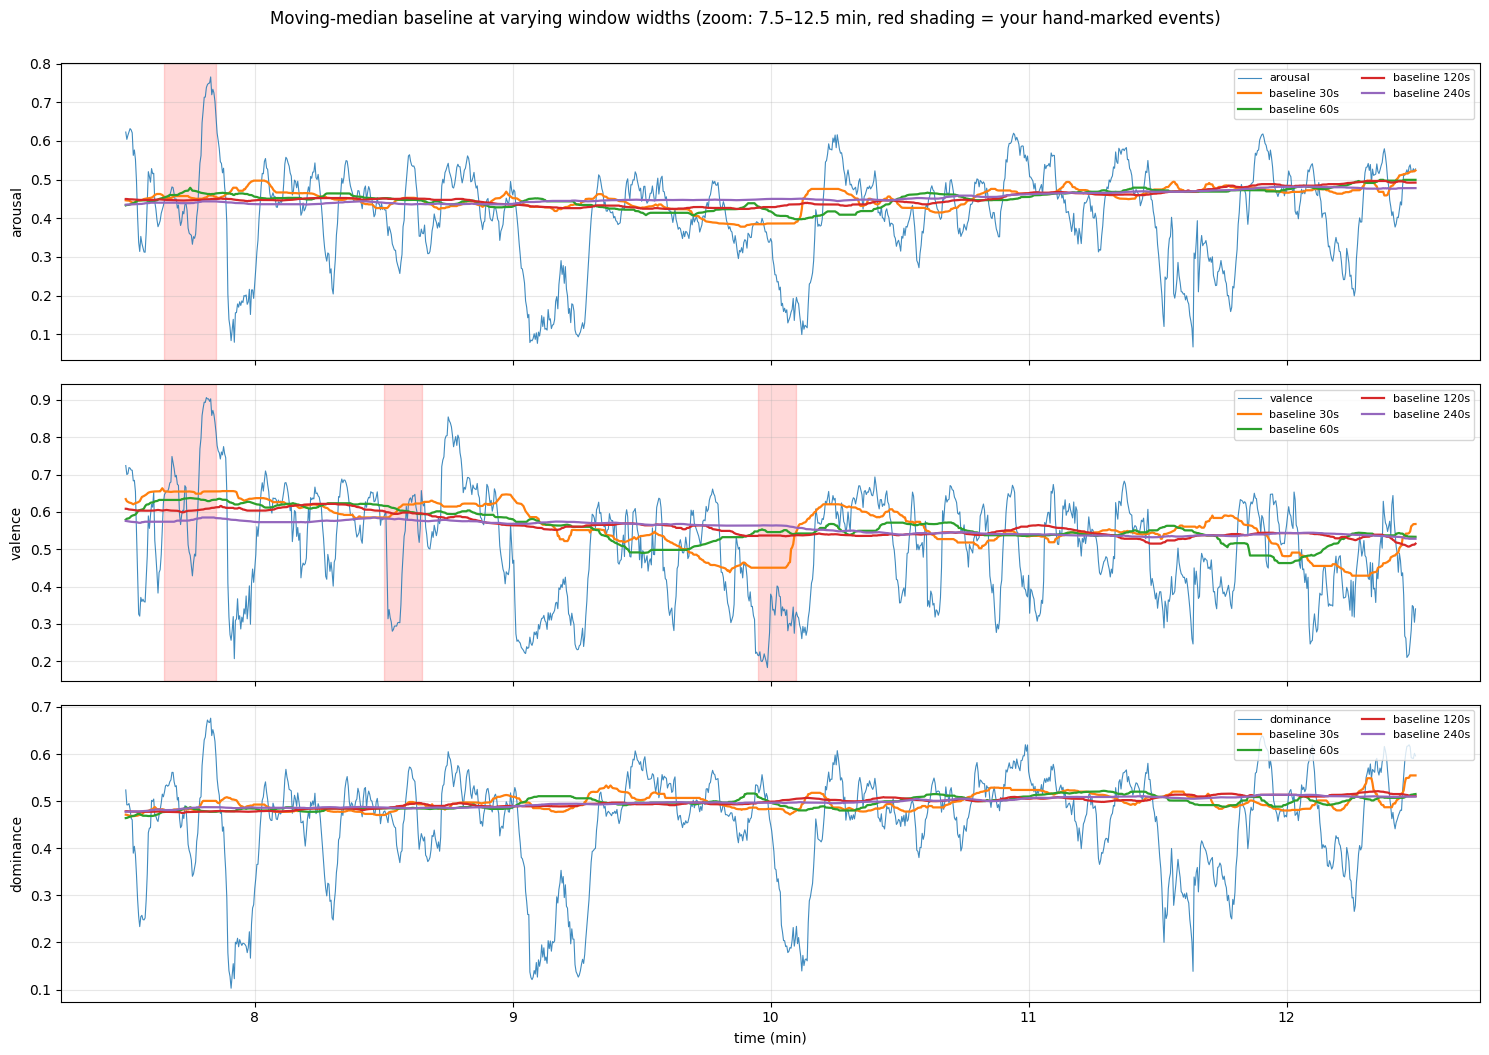

In [52]:
def moving_median_speech(sig, valid, window_sec, hop_sec):
    """Centered moving median over speech-only frames.

    Frames where `valid=False` are excluded from the median (the window
    looks past them). Returns NaN where the window contains no speech frames.
    """
    half = int(round(window_sec / hop_sec / 2))
    n = len(sig)
    width = 2 * half + 1
    masked = np.where(valid, sig, np.nan)
    padded = np.full(n + 2 * half, np.nan)
    padded[half:half + n] = masked
    windows = sliding_window_view(padded, width)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        out = np.nanmedian(windows, axis=1)
    return out

WINDOWS_SEC = [30, 60, 120, 240]
WINDOW_COLORS = ["C1", "C2", "C3", "C4"]

valid = coverage >= USABLE_COVERAGE
baselines = {
    (name, w): moving_median_speech(sig, valid, w, HOP_SEC)
    for name, sig in SIGNALS.items()
    for w in WINDOWS_SEC
}

# Plot one zoom region per signal to compare window widths
demo_zoom = ZOOM_WINDOWS_SEC[0]
times_min = (np.arange(n_frames) * HOP_SEC + WINDOW_SEC / 2) / 60
in_zoom = (times_min*60 >= demo_zoom[0]) & (times_min*60 <= demo_zoom[1])

fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(15, 3.5*len(SIGNALS)),
                         squeeze=False, sharex=True)
for ax, (name, sig) in zip(axes[:, 0], SIGNALS.items()):
    ax.plot(times_min[in_zoom], sig[in_zoom], "C0-", lw=0.8, alpha=0.85,
            label=name)
    for w, col in zip(WINDOWS_SEC, WINDOW_COLORS):
        ax.plot(times_min[in_zoom], baselines[(name, w)][in_zoom],
                color=col, lw=1.6, label=f"baseline {w}s")
    for sn, lbl, ms, me in MARKED_EVENTS:
        if sn != name:
            continue
        if me < demo_zoom[0] or ms > demo_zoom[1]:
            continue
        ax.axvspan(ms/60, me/60, color="red", alpha=0.15)
    ax.set_ylabel(name)
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
axes[-1, 0].set_xlabel("time (min)")
fig.suptitle(
    f"Moving-median baseline at varying window widths "
    f"(zoom: {demo_zoom[0]/60:.1f}–{demo_zoom[1]/60:.1f} min, "
    f"red shading = your hand-marked events)",
    y=1.0,
)
plt.tight_layout()
plt.show()


## 6. Deviation magnitude distribution

For each window width, plot the histogram of `|signal − baseline|` over all
valid speech frames (log-y so the tail is visible).

**Reading this plot is the key step.** The bulk of the histogram (left)
is normal-speech wiggle. Events live in the **upper tail**. The threshold
that separates them is wherever the curve flattens out — typically a
factor of ~3-5 above the median deviation. The narrower the window, the
shorter the tail (because narrow windows track events into themselves).


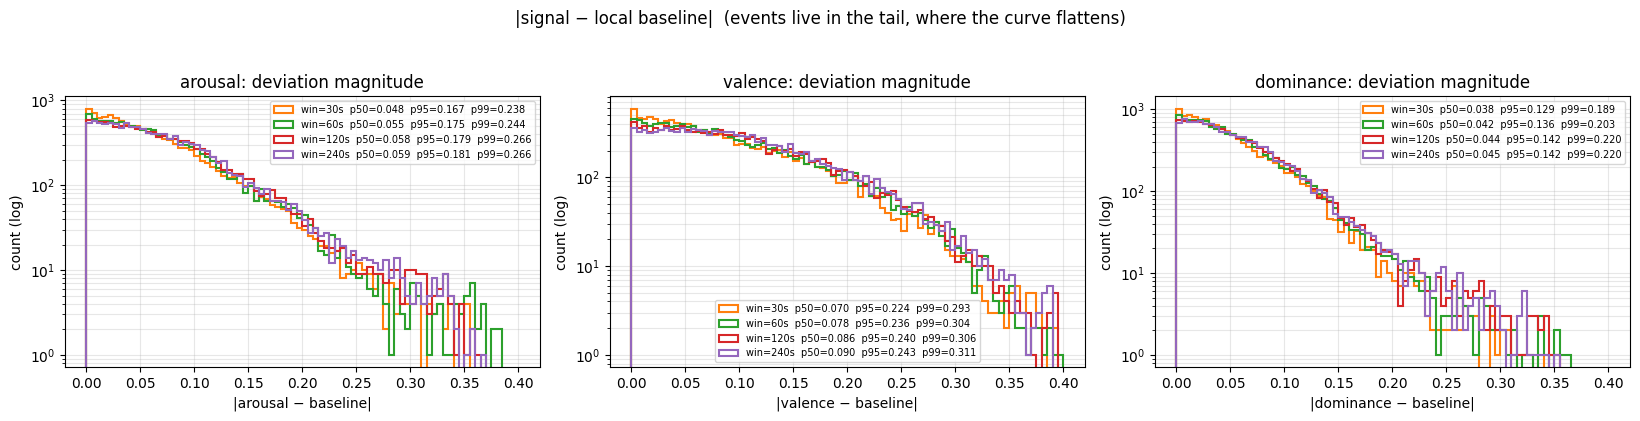

In [53]:
fig, axes = plt.subplots(1, len(SIGNALS), figsize=(5.5*len(SIGNALS), 4),
                         squeeze=False)
for ax, (name, sig) in zip(axes[0], SIGNALS.items()):
    for w, col in zip(WINDOWS_SEC, WINDOW_COLORS):
        bl = baselines[(name, w)]
        d = np.abs(sig - bl)[valid & np.isfinite(bl)]
        p99 = np.percentile(d, 99)
        ax.hist(
            d, bins=80, range=(0, max(0.4, p99*1.2)),
            histtype="step", linewidth=1.5, color=col,
            label=(f"win={w}s  p50={np.median(d):.3f}  "
                   f"p95={np.percentile(d, 95):.3f}  p99={p99:.3f}"),
        )
    ax.set_xlabel(f"|{name} − baseline|")
    ax.set_ylabel("count (log)")
    ax.set_yscale("log")
    ax.set_title(f"{name}: deviation magnitude")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, which="both")
plt.suptitle(
    "|signal − local baseline|  (events live in the tail, where the "
    "curve flattens)",
    y=1.04,
)
plt.tight_layout()
plt.show()


## 7. Tentative detector — parameter sweep

The whole detector, from scratch:

```
events(signal, baseline, threshold, min_dur, max_gap):
  for sign in (+1, -1):
    mask  = (sign * (signal - baseline)) >= threshold  AND  valid
    runs  = consecutive-True intervals of mask
    runs  = bridge runs separated by <= max_gap frames
    keep  = runs of length >= min_dur frames
```

That's the whole thing. We sweep `threshold` over a few values and report
event count and duration distribution per signal. Look for the
**threshold where event count stabilizes** — below it you're firing on
noise; above it you start dropping real events.


In [54]:
def find_runs(mask):
    if mask.size == 0 or not mask.any():
        return []
    ed = np.diff(mask.astype(np.int8), prepend=0, append=0)
    starts = np.where(ed == 1)[0]
    ends = np.where(ed == -1)[0]
    return list(zip(starts.tolist(), ends.tolist()))

def detect_events(sig, valid, baseline, threshold,
                  min_dur_frames, max_gap_frames):
    """Return list of (start_idx, end_idx, sign). end is exclusive."""
    deviation = np.where(valid & np.isfinite(baseline), sig - baseline, 0.0)
    out = []
    for sign, lbl in [(+1, "+"), (-1, "-")]:
        mask = (sign * deviation) >= threshold
        runs = find_runs(mask)
        bridged = []
        for s, e in runs:
            if bridged and s - bridged[-1][1] <= max_gap_frames:
                bridged[-1][1] = e
            else:
                bridged.append([s, e])
        for s, e in bridged:
            if (e - s) >= min_dur_frames:
                out.append((s, e, lbl))
    return sorted(out)

BASELINE_WINDOW_SEC = 90
THRESHOLDS = [0.05, 0.075, 0.10, 0.125, 0.15, 0.20]
MIN_DURATION_SEC = 3.0
MAX_GAP_SEC = 1.0

min_dur_fr = int(round(MIN_DURATION_SEC / HOP_SEC))
max_gap_fr = int(round(MAX_GAP_SEC / HOP_SEC))
sweep_baselines = {
    name: moving_median_speech(sig, valid, BASELINE_WINDOW_SEC, HOP_SEC)
    for name, sig in SIGNALS.items()
}

rows = []
for name, sig in SIGNALS.items():
    bl = sweep_baselines[name]
    for thr in THRESHOLDS:
        ev = detect_events(sig, valid, bl, thr, min_dur_fr, max_gap_fr)
        durs = (np.array([(e - s) * HOP_SEC for s, e, _ in ev])
                if ev else np.array([]))
        rows.append({
            "signal":               name,
            "threshold":            thr,
            "n_events":             len(ev),
            "n_pos":                sum(1 for _, _, s in ev if s == "+"),
            "n_neg":                sum(1 for _, _, s in ev if s == "-"),
            "median_dur_sec":       float(np.median(durs)) if durs.size else np.nan,
            "p95_dur_sec":          float(np.percentile(durs, 95)) if durs.size else np.nan,
            "max_dur_sec":          float(durs.max()) if durs.size else np.nan,
            "total_event_time_sec": float(durs.sum()),
        })
sweep_df = pd.DataFrame(rows).round(3)
print(f"Sweep: baseline_window={BASELINE_WINDOW_SEC}s, "
      f"min_duration={MIN_DURATION_SEC}s, max_gap_bridged={MAX_GAP_SEC}s")
sweep_df


Sweep: baseline_window=90s, min_duration=3.0s, max_gap_bridged=1.0s


,signal,threshold,n_events,n_pos,n_neg,median_dur_sec,p95_dur_sec,max_dur_sec,total_event_time_sec
0,arousal,0.050,246,118,128,4.50,10.188,17.50,1315.25
1,arousal,0.075,164,80,84,4.25,9.425,13.00,809.25
2,arousal,0.100,99,50,49,3.75,8.250,11.75,451.50
3,arousal,0.125,62,28,34,3.50,6.962,10.50,249.75
4,arousal,0.150,33,16,17,3.50,5.700,7.00,125.00
5,arousal,0.200,8,4,4,3.25,6.037,7.00,30.25
6,valence,0.050,307,141,166,4.75,12.600,19.50,1833.25
7,valence,0.075,254,115,139,4.50,11.250,18.25,1387.50
8,valence,0.100,199,89,110,4.25,9.800,14.75,996.25
9,valence,0.125,144,58,86,4.00,8.750,14.50,669.25


## 8. Zoom into your hand-marked regions

For each (zoom window × signal), we show:

- **top panel**: signal (blue), baseline (black), detected events
  (green = positive deviation, orange = negative), your hand-marked events
  (red rectangles)
- **bottom panel**: `|signal − baseline|` with the threshold line

This is the eye-test of the algorithm: a green/orange band should land
on top of every red rectangle, and ideally not many other places.
Tweak `CHOSEN_*` parameters in the cell below and re-run if needed.


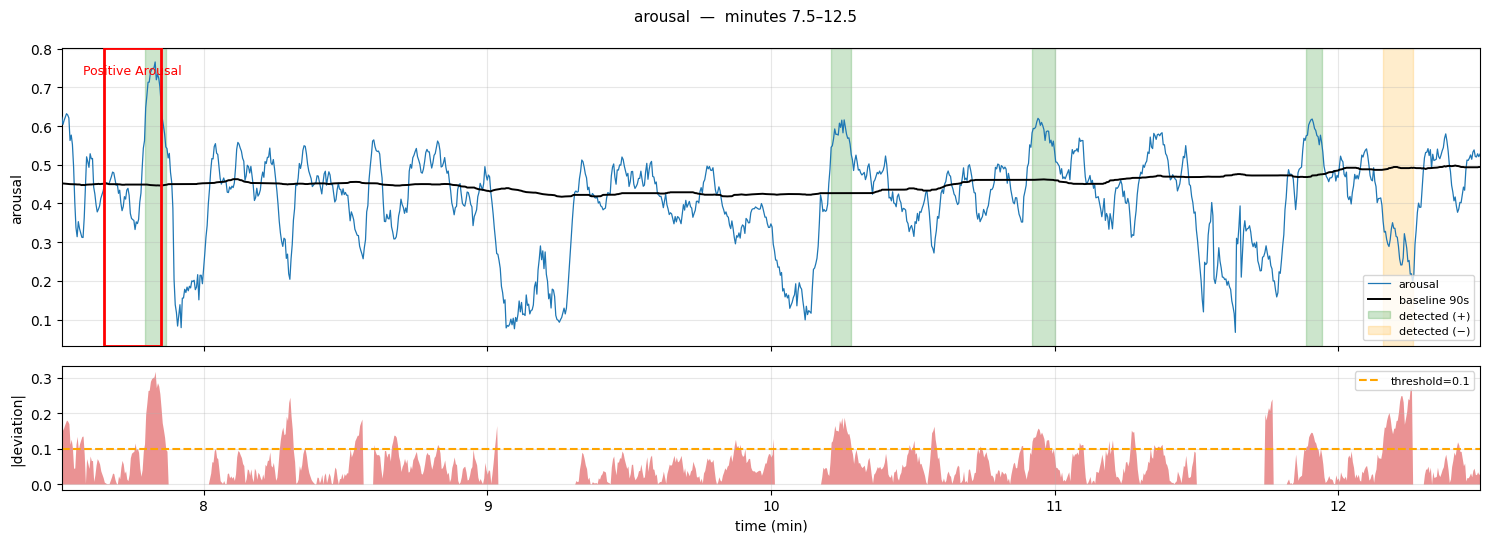

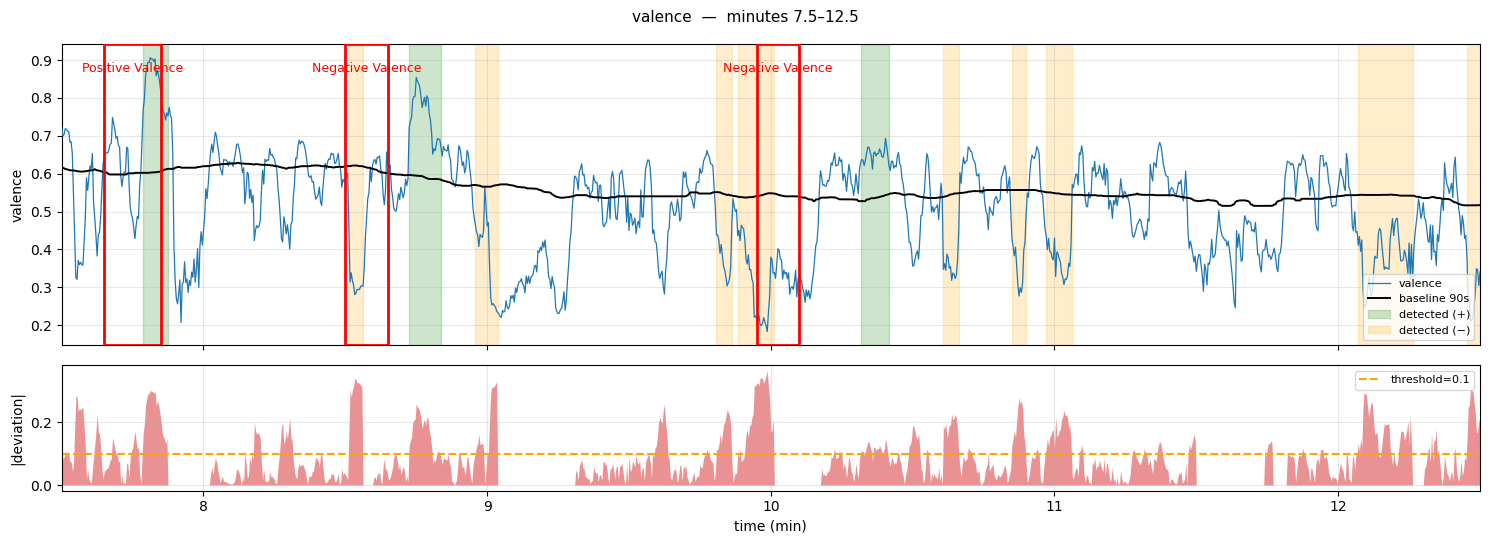

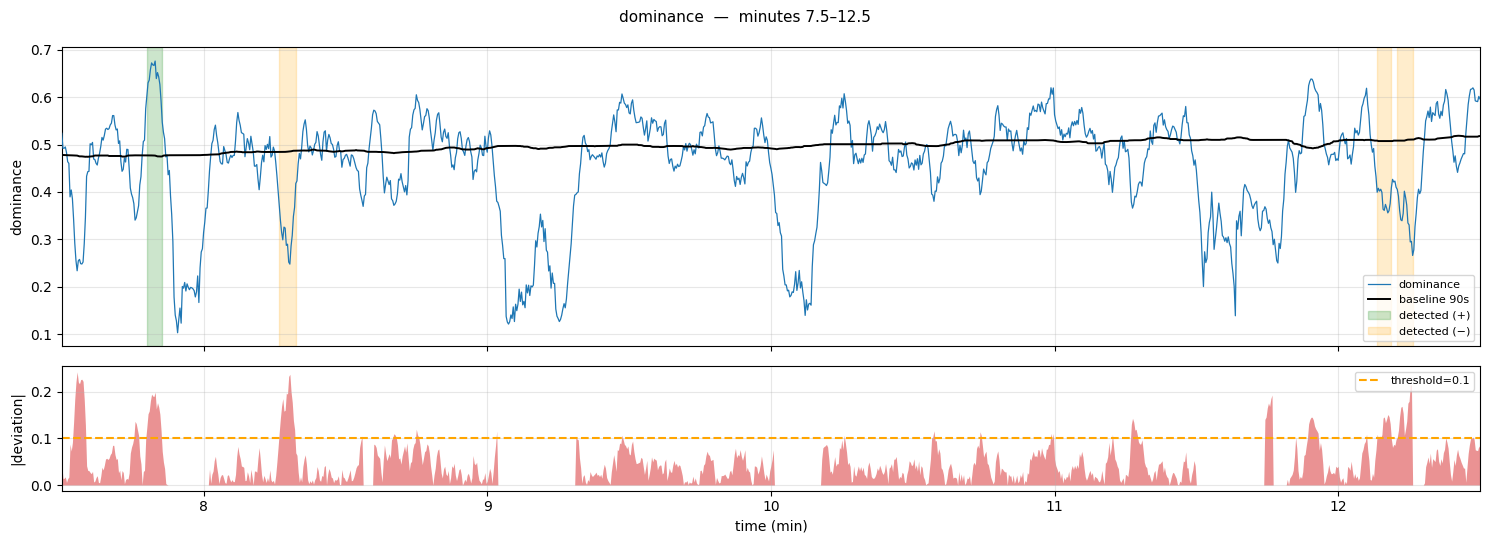

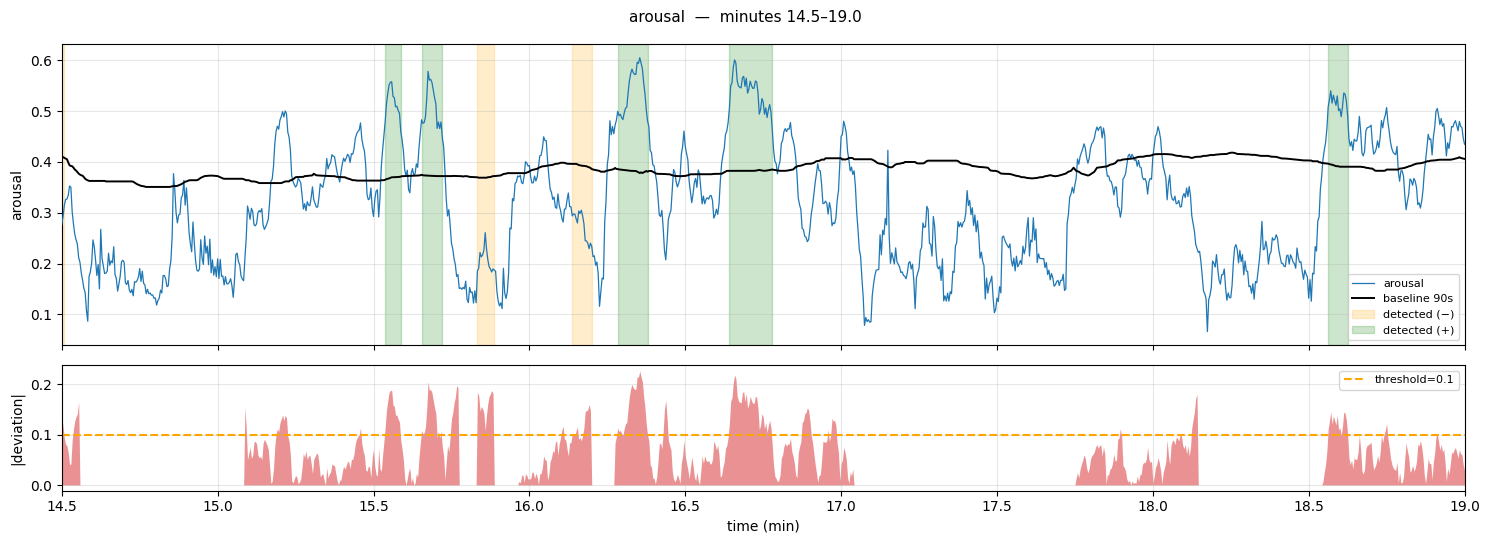

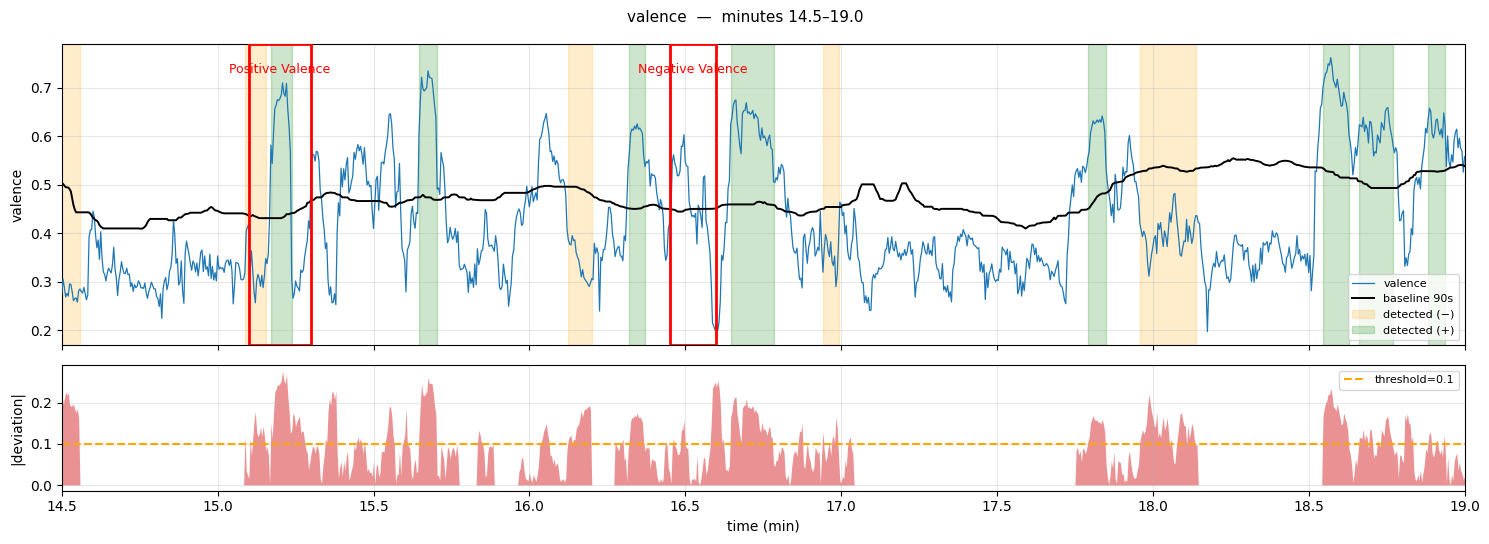

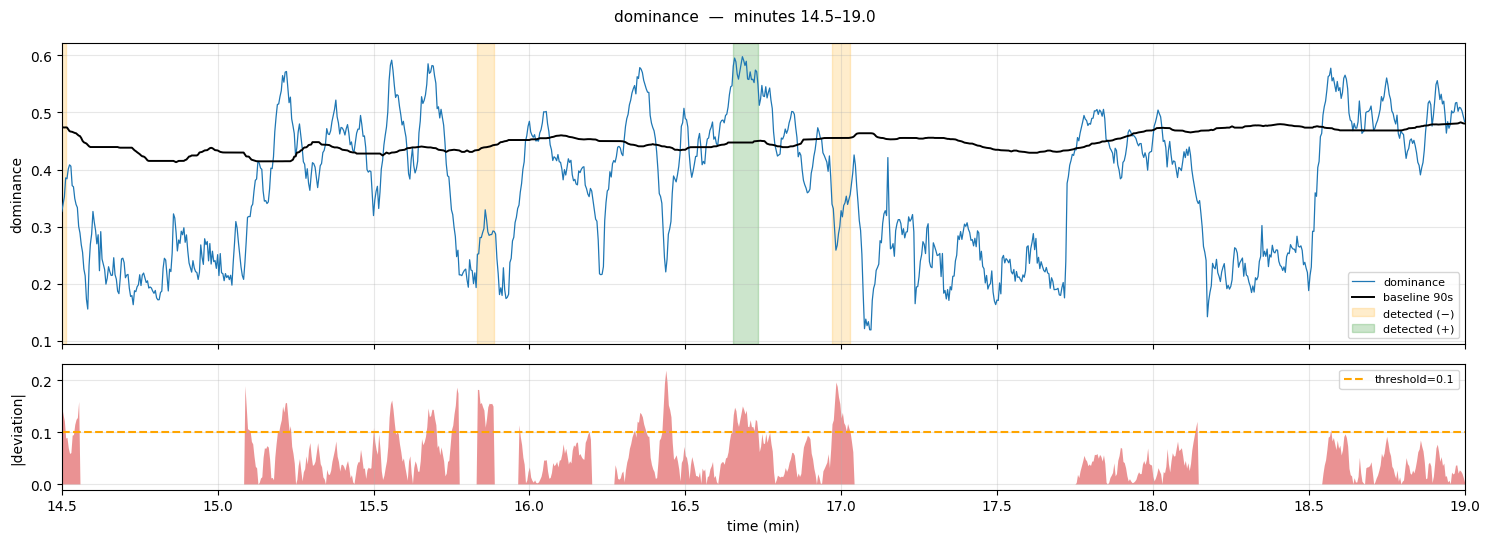

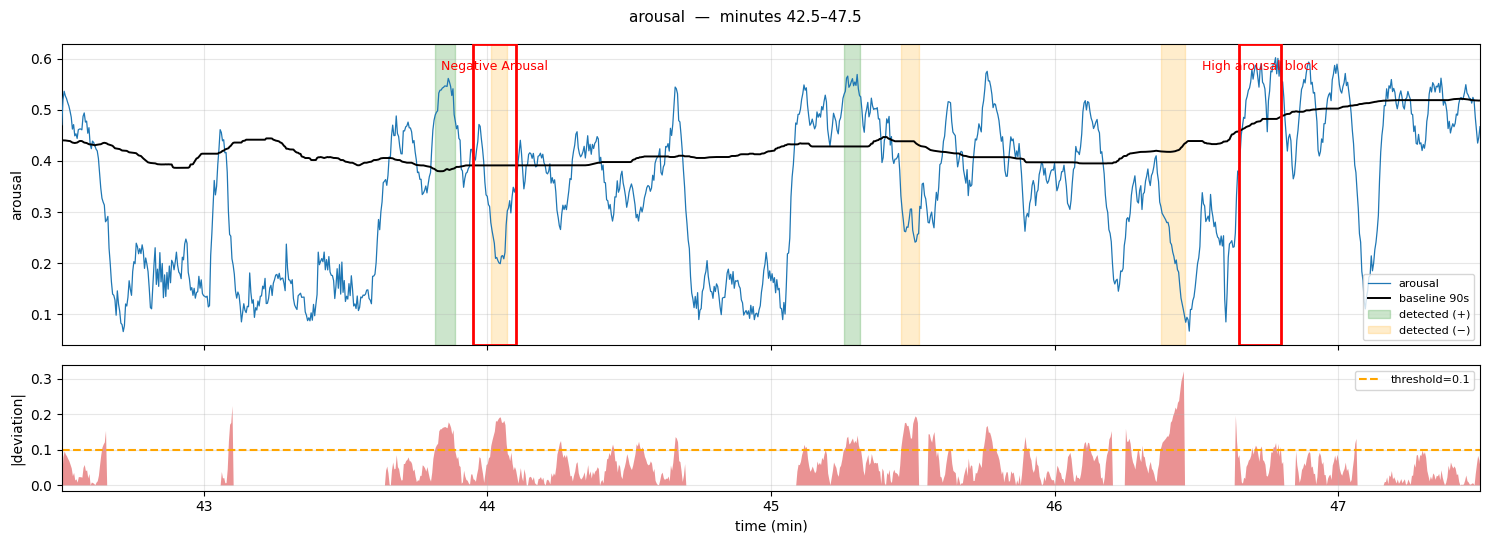

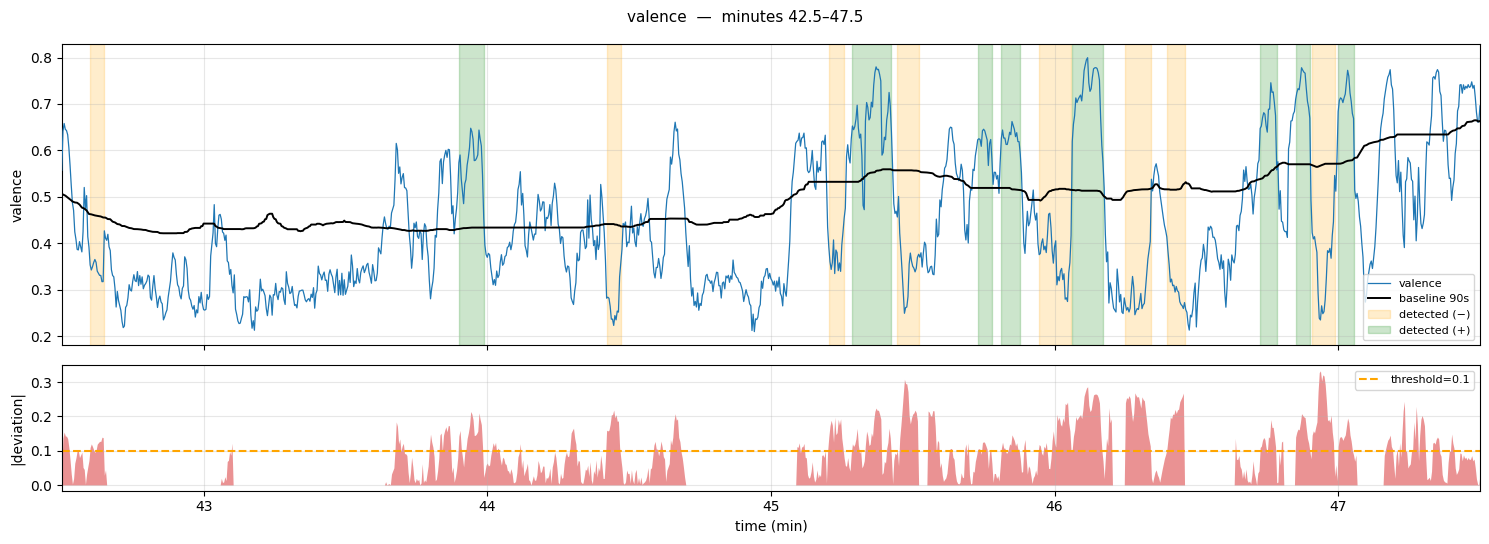

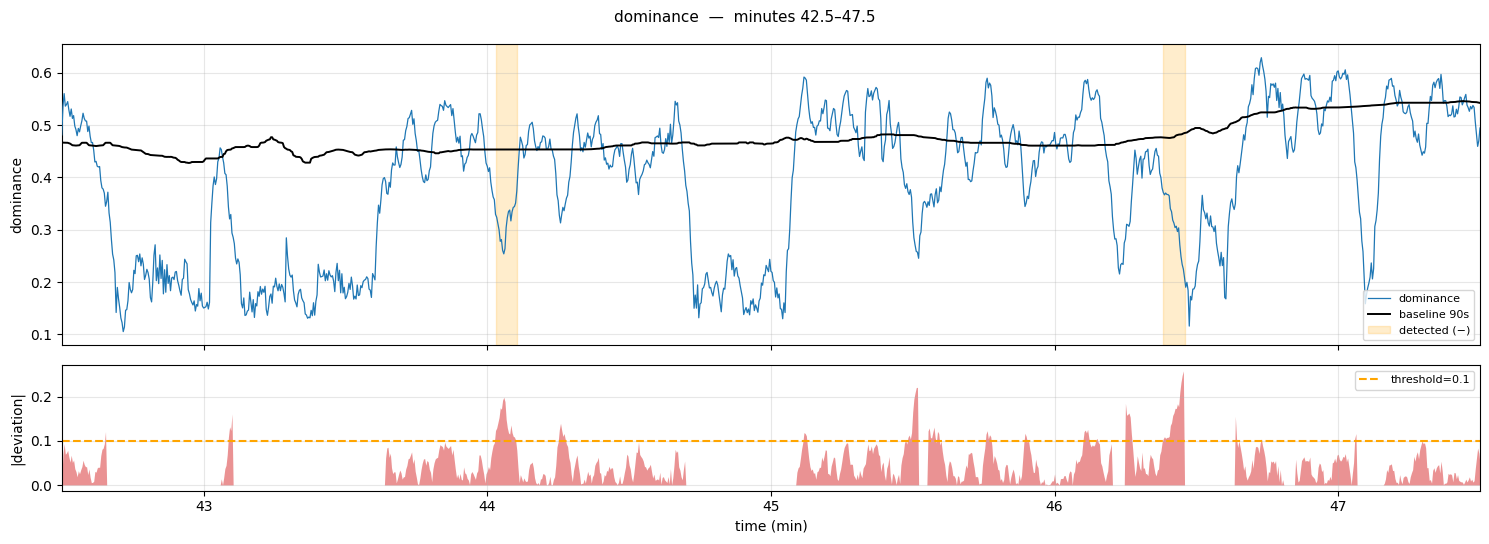

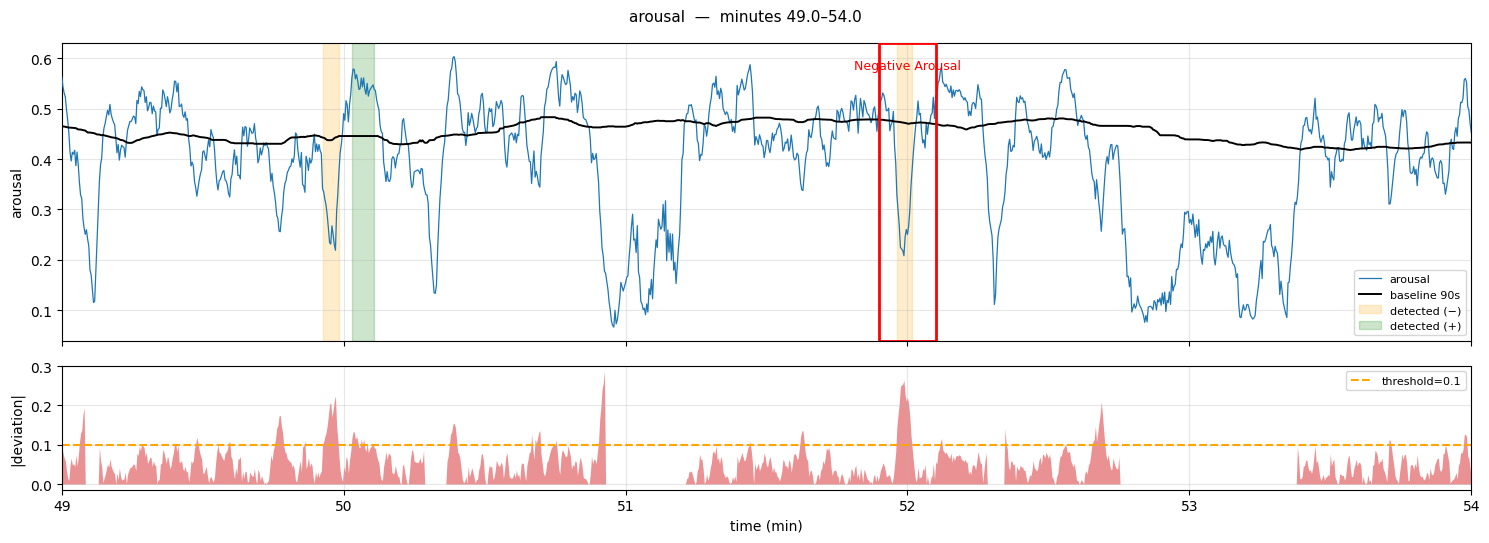

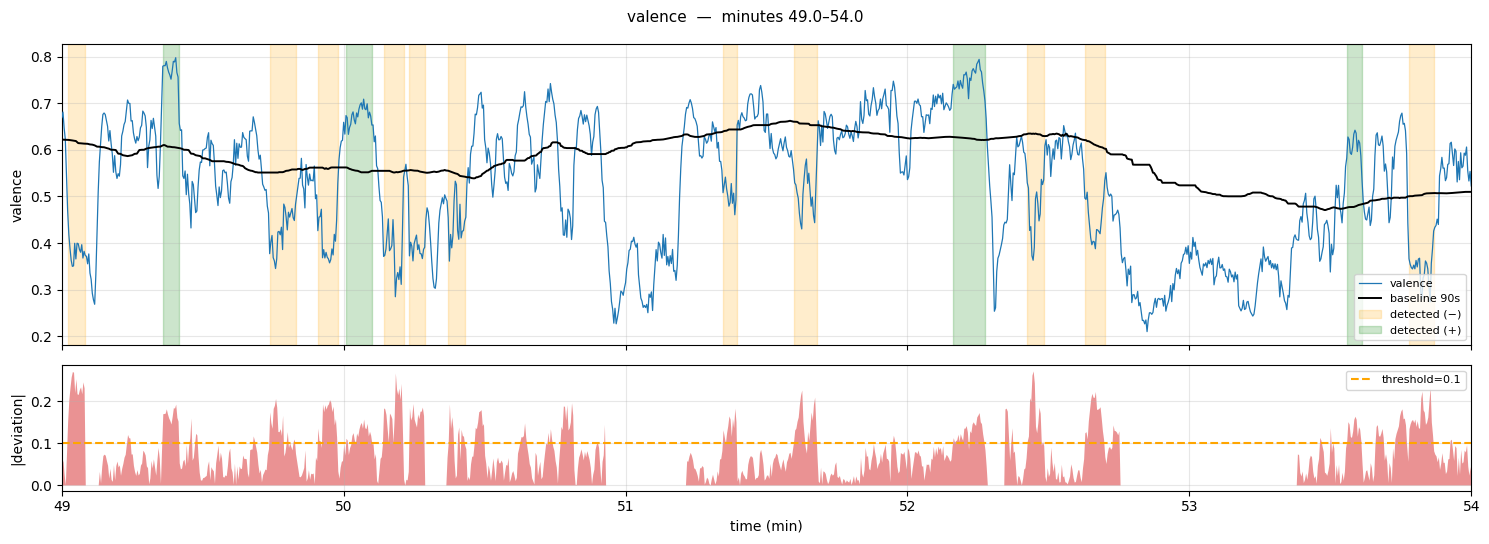

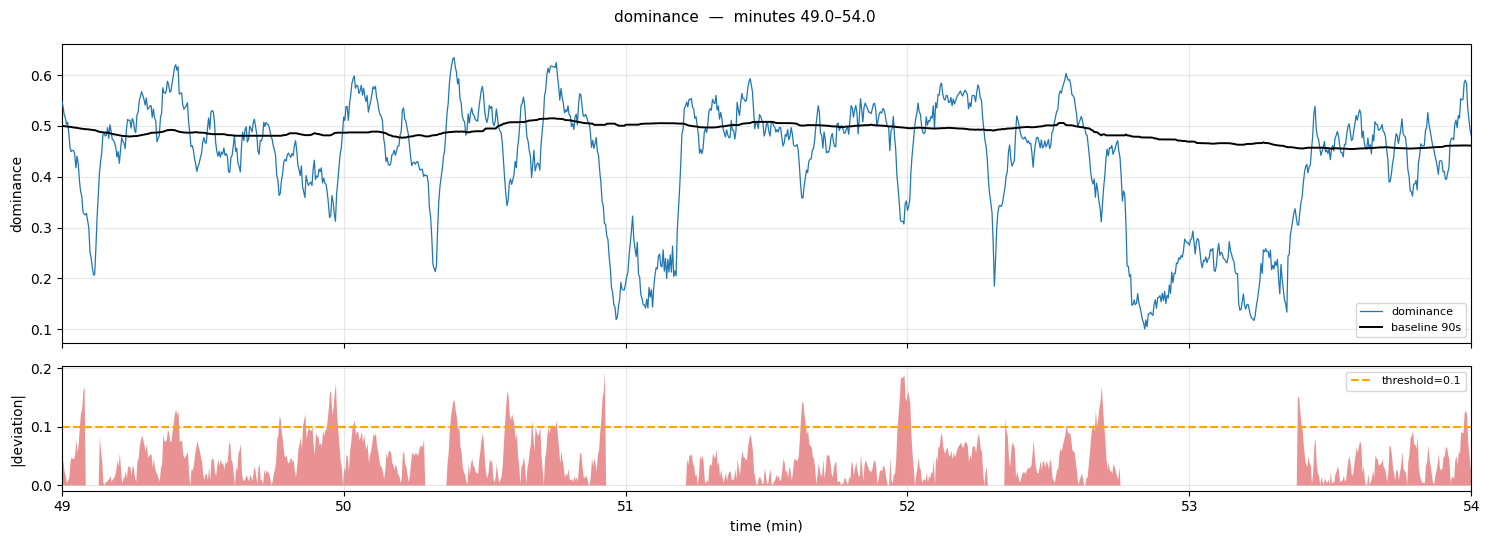

In [55]:
# Choose final detection parameters based on the sweep above
CHOSEN_THRESHOLD = 0.10
CHOSEN_BASELINE_WINDOW_SEC = 90
CHOSEN_MIN_DURATION_SEC = 3.0
CHOSEN_MAX_GAP_SEC = 1.0

chosen_min_dur_fr = int(round(CHOSEN_MIN_DURATION_SEC / HOP_SEC))
chosen_max_gap_fr = int(round(CHOSEN_MAX_GAP_SEC / HOP_SEC))
chosen_baselines = {
    name: moving_median_speech(sig, valid,
                               CHOSEN_BASELINE_WINDOW_SEC, HOP_SEC)
    for name, sig in SIGNALS.items()
}
chosen_events = {
    name: detect_events(sig, valid, chosen_baselines[name],
                        CHOSEN_THRESHOLD, chosen_min_dur_fr, chosen_max_gap_fr)
    for name, sig in SIGNALS.items()
}

def zoom_plot(name, t0_sec, t1_sec):
    sig = SIGNALS[name]
    bl = chosen_baselines[name]
    ev = chosen_events[name]

    in_zoom = (times_min*60 >= t0_sec) & (times_min*60 <= t1_sec)
    fig, axes = plt.subplots(2, 1, figsize=(15, 5.5), sharex=True,
                              gridspec_kw={"height_ratios": [2.4, 1]})

    ax = axes[0]
    ax.plot(times_min[in_zoom], sig[in_zoom], color="C0", lw=0.9,
            label=name, zorder=3)
    ax.plot(times_min[in_zoom], bl[in_zoom], color="black", lw=1.4,
            label=f"baseline {CHOSEN_BASELINE_WINDOW_SEC}s", zorder=4)

    seen_pos = seen_neg = False
    for s_idx, e_idx, sign in ev:
        ts = (s_idx * HOP_SEC + WINDOW_SEC/2) / 60
        te = (e_idx * HOP_SEC + WINDOW_SEC/2) / 60
        if te*60 < t0_sec or ts*60 > t1_sec:
            continue
        col = "green" if sign == "+" else "orange"
        lbl = None
        if sign == "+" and not seen_pos:
            lbl = "detected (+)"; seen_pos = True
        elif sign == "-" and not seen_neg:
            lbl = "detected (−)"; seen_neg = True
        ax.axvspan(ts, te, color=col, alpha=0.20, zorder=1, label=lbl)

    ymin, ymax = ax.get_ylim()
    for sn, mlbl, ms, me in MARKED_EVENTS:
        if sn != name:
            continue
        if me < t0_sec or ms > t1_sec:
            continue
        ax.axvspan(ms/60, me/60, facecolor="none", edgecolor="red",
                   linewidth=2, zorder=5)
        ax.text((ms+me)/2/60, ymax * 0.95, mlbl,
                color="red", fontsize=9, ha="center", va="top", zorder=6)

    ax.set_ylabel(name)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    abs_dev = np.where(valid & np.isfinite(bl), np.abs(sig - bl), 0.0)
    ax.fill_between(times_min[in_zoom], 0, abs_dev[in_zoom],
                     color="C3", alpha=0.5, lw=0)
    ax.axhline(CHOSEN_THRESHOLD, color="orange", ls="--", lw=1.5,
               label=f"threshold={CHOSEN_THRESHOLD}")
    ax.set_xlabel("time (min)")
    ax.set_ylabel("|deviation|")
    ax.set_xlim(t0_sec/60, t1_sec/60)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"{name}  —  minutes "
                 f"{t0_sec/60:.1f}–{t1_sec/60:.1f}",
                 fontsize=11)
    plt.tight_layout()
    plt.show()

for t0, t1 in ZOOM_WINDOWS_SEC:
    for name in SIGNALS:
        zoom_plot(name, t0, t1)


## 9. Full-recording overview

Bird's-eye view of every detected event across the recording. Useful for
spotting:

- regions that produce far more events than the rest (might be a
  microphone/speaker problem rather than emotion)
- correlation across signals (does an arousal event coincide with
  a valence event?)
- whether the total event count and total event-time look reasonable
  (a few dozen events per hour is normal; hundreds suggests the threshold
  is too low; a handful suggests it's too high)


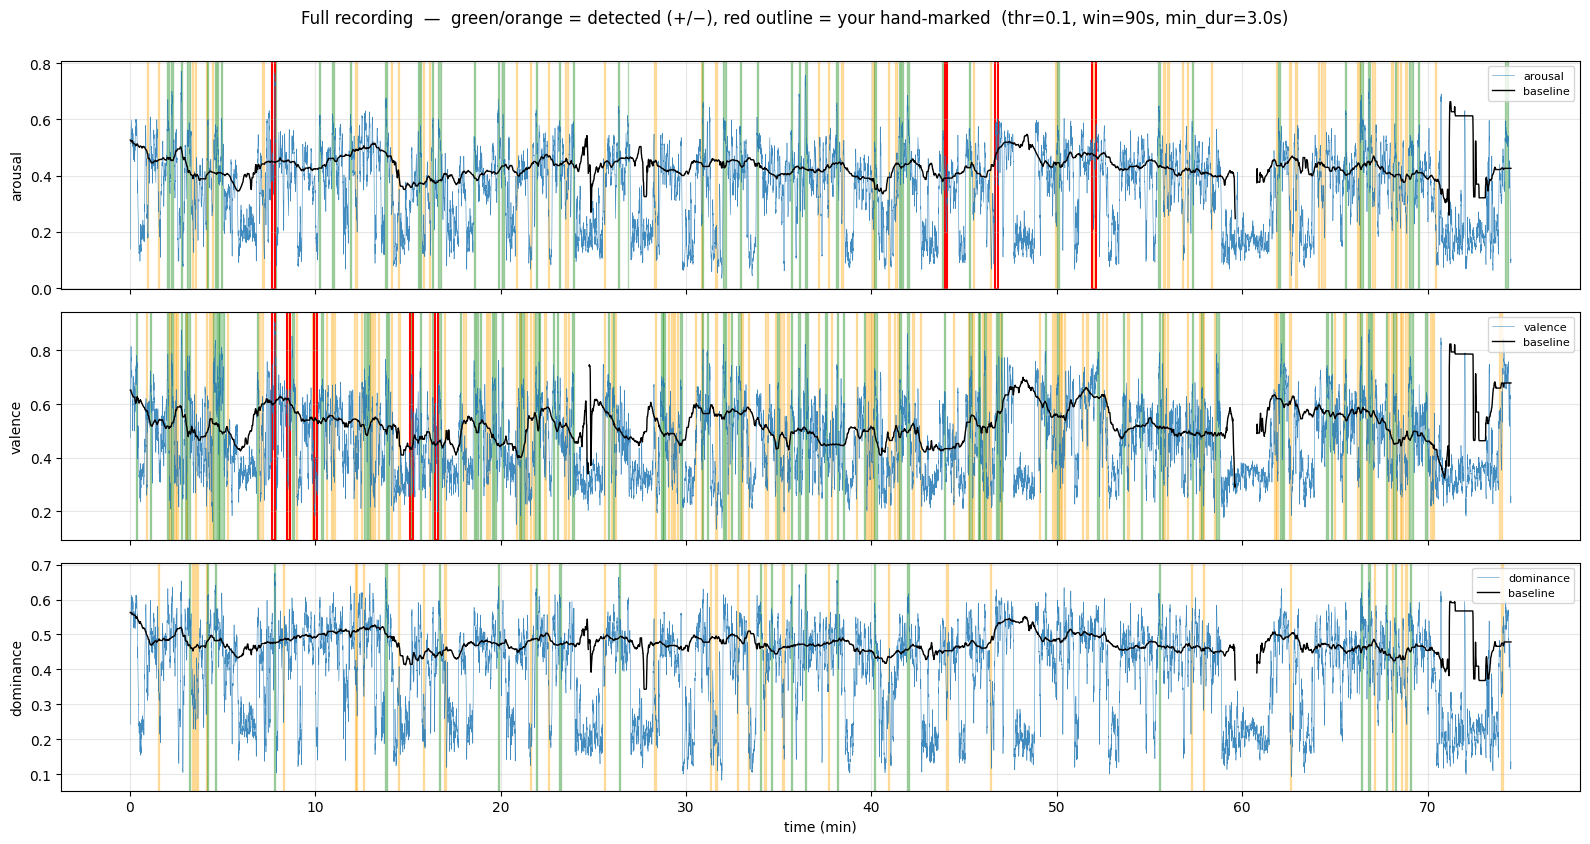


Final detector parameters:
  threshold          = 0.1
  baseline_window    = 90s
  min_duration       = 3.0s
  max_gap_bridged    = 1.0s


,signal,n_events,n_pos,n_neg,median_dur_sec,p95_dur_sec,events_per_min
0,arousal,99,50,49,3.75,8.25,1.328
1,valence,199,89,110,4.25,9.80,2.670
2,dominance,57,23,34,3.50,6.80,0.765


In [56]:
fig, axes = plt.subplots(len(SIGNALS), 1, figsize=(16, 2.8*len(SIGNALS)),
                         squeeze=False, sharex=True)
for ax, (name, sig) in zip(axes[:, 0], SIGNALS.items()):
    bl = chosen_baselines[name]
    ax.plot(times_min, sig, color="C0", lw=0.4, alpha=0.85, label=name)
    ax.plot(times_min, bl, color="black", lw=1.0, label="baseline")

    for s_idx, e_idx, sign in chosen_events[name]:
        ts = (s_idx * HOP_SEC + WINDOW_SEC/2) / 60
        te = (e_idx * HOP_SEC + WINDOW_SEC/2) / 60
        col = "green" if sign == "+" else "orange"
        ax.axvspan(ts, te, color=col, alpha=0.30)

    for sn, _, ms, me in MARKED_EVENTS:
        if sn != name:
            continue
        ax.axvspan(ms/60, me/60, facecolor="none", edgecolor="red",
                   linewidth=1.5)

    ax.set_ylabel(name)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
axes[-1, 0].set_xlabel("time (min)")
fig.suptitle(
    f"Full recording  —  green/orange = detected (+/−), "
    f"red outline = your hand-marked  "
    f"(thr={CHOSEN_THRESHOLD}, win={CHOSEN_BASELINE_WINDOW_SEC}s, "
    f"min_dur={CHOSEN_MIN_DURATION_SEC}s)",
    y=1.0,
)
plt.tight_layout()
plt.show()

# Final summary table
final_rows = []
for name in SIGNALS:
    ev = chosen_events[name]
    durs = (np.array([(e - s) * HOP_SEC for s, e, _ in ev])
            if ev else np.array([]))
    final_rows.append({
        "signal":         name,
        "n_events":       len(ev),
        "n_pos":          sum(1 for _, _, s in ev if s == "+"),
        "n_neg":          sum(1 for _, _, s in ev if s == "-"),
        "median_dur_sec": float(np.median(durs)) if durs.size else np.nan,
        "p95_dur_sec":    float(np.percentile(durs, 95)) if durs.size else np.nan,
        "events_per_min": float(len(ev) / (recording_dur_sec/60)),
    })
print(f"\nFinal detector parameters:")
print(f"  threshold          = {CHOSEN_THRESHOLD}")
print(f"  baseline_window    = {CHOSEN_BASELINE_WINDOW_SEC}s")
print(f"  min_duration       = {CHOSEN_MIN_DURATION_SEC}s")
print(f"  max_gap_bridged    = {CHOSEN_MAX_GAP_SEC}s")
pd.DataFrame(final_rows).round(3)
